# 6. Redes Neuronales Recurrentes (RNN/LSTM)

En este notebook aprenderás a construir y entrenar redes recurrentes (RNN y LSTM) para tareas de series temporales, usando TensorFlow/Keras.

## Objetivo
- Comprender la teoría y arquitectura de las redes recurrentes (RNN y LSTM).
- Implementar y entrenar una RNN/LSTM para predicción de series temporales.
- Comparar cuantitativamente RNN vs LSTM.
- Aplicar buenas prácticas para entrenamiento.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [04 (MLP)](./04_redes_neuronales_capa_densa.ipynb) y [05 (CNN)](./05_redes_convolucionales_cnn.ipynb).

- Conceptos de redes neuronales, entrenamiento con Keras, y callbacks.

## 1. Introducción teórica

Las redes neuronales recurrentes (RNN) procesan secuencias manteniendo una memoria de estados anteriores. Las LSTM resuelven el problema del desvanecimiento del gradiente.

| Modelo | Memoria | Ventaja | Desventaja |
|--------|---------|---------|------------|
| **RNN simple** | Corto plazo | Rápida, sencilla | No captura dependencias largas |
| **LSTM** | Largo plazo | Puertas de control de memoria | Más lenta, más parámetros |
| **GRU** | Largo plazo | Más simple que LSTM, similar rendimiento | Menos flexible |

## 2. Importación de librerías

In [1]:
# === Reproducibilidad ===
import random
import numpy as np
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt

# === Suprimir logs de TensorFlow/XLA ANTES de importar TF ===
# TF_CPP_MIN_LOG_LEVEL: 0=INFO, 1=WARNING, 2=ERROR, 3=FATAL
# Con '2' los logs INFO del compilador XLA (dot_merger.cc, etc.) se escapan
# porque usan abseil C++ logging. Con '3' se eliminan todos salvo FATAL.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(SEED)

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 3. Generación y exploración de la serie temporal

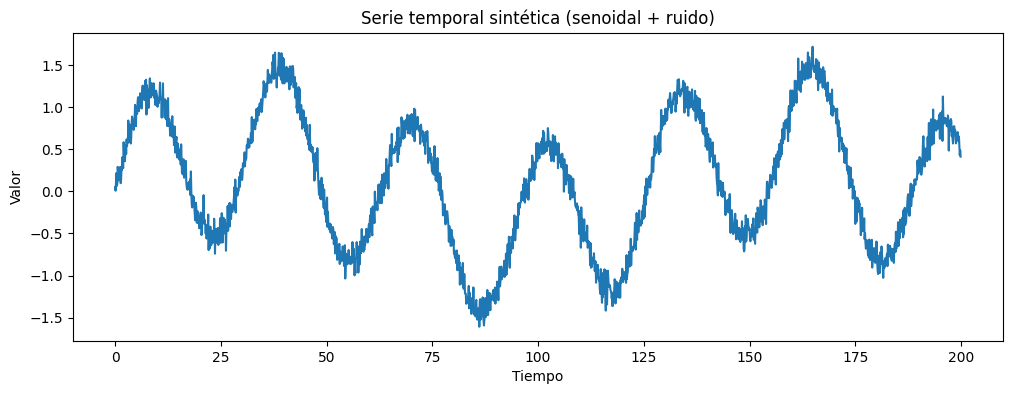

Longitud de la serie: 2000 puntos


In [2]:
t = np.arange(0, 200, 0.1)
data = np.sin(0.2 * t) + 0.5 * np.sin(0.05 * t) + 0.1 * np.random.randn(len(t))

plt.figure(figsize=(12,4))
plt.plot(t, data)
plt.title('Serie temporal sintética (senoidal + ruido)')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.show()
print(f'Longitud de la serie: {len(data)} puntos')

## 4. Preprocesamiento de secuencias

In [3]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1)).flatten()

X, y_seq = create_sequences(data_scaled, seq_length)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (1576, 30, 1), y_train: (1576,)
X_test: (394, 30, 1), y_test: (394,)


## 5. RNN simple

In [4]:
model_rnn = keras.Sequential([
    keras.layers.Input(shape=(seq_length, 1)),
    keras.layers.SimpleRNN(32, activation='tanh'),
    keras.layers.Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')
history_rnn = model_rnn.fit(X_train, y_train, epochs=20, batch_size=32,
                            validation_split=0.2, verbose=1)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0215 - val_loss: 0.0037
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0

## 6. LSTM

In [5]:
model_lstm = keras.Sequential([
    keras.layers.Input(shape=(seq_length, 1)),
    keras.layers.LSTM(32),
    keras.layers.Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
history_lstm = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32,
                              validation_split=0.2, verbose=1)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.1006 - val_loss: 0.0057
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - val_loss: 0.0025
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

## 7. Comparación cuantitativa RNN vs LSTM

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
RNN  — MSE: 0.012995, MAE: 0.089168
LSTM — MSE: 0.011126, MAE: 0.082091

LSTM tiene menor error en este caso.


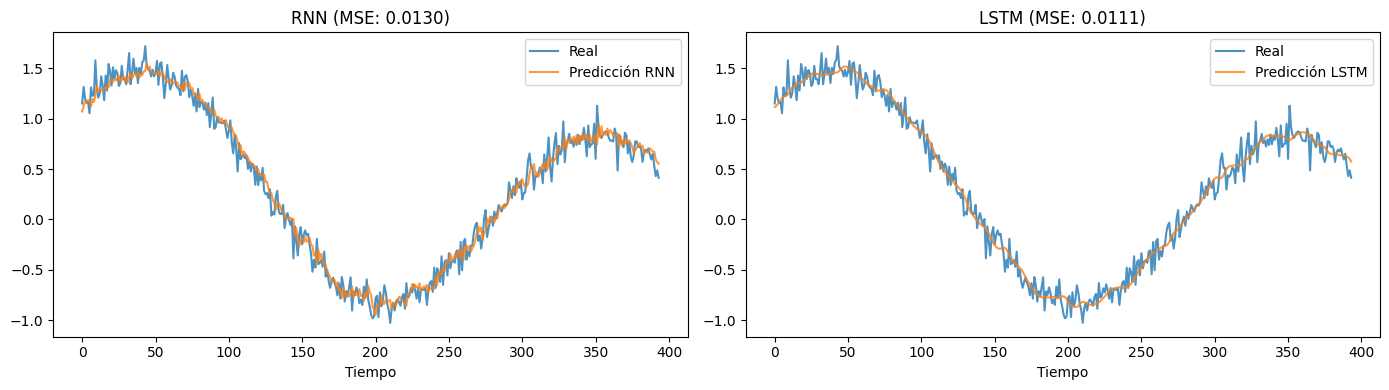

In [6]:
# Predicciones
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)

# Invertir normalización
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
pred_rnn_inv = scaler.inverse_transform(pred_rnn).flatten()
pred_lstm_inv = scaler.inverse_transform(pred_lstm).flatten()

# Métricas
mse_rnn = mean_squared_error(y_test_inv, pred_rnn_inv)
mae_rnn = mean_absolute_error(y_test_inv, pred_rnn_inv)
mse_lstm = mean_squared_error(y_test_inv, pred_lstm_inv)
mae_lstm = mean_absolute_error(y_test_inv, pred_lstm_inv)

print(f'RNN  — MSE: {mse_rnn:.6f}, MAE: {mae_rnn:.6f}')
print(f'LSTM — MSE: {mse_lstm:.6f}, MAE: {mae_lstm:.6f}')
print(f'\n{"LSTM" if mse_lstm < mse_rnn else "RNN"} tiene menor error en este caso.')

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y_test_inv, label='Real', alpha=0.8)
axes[0].plot(pred_rnn_inv, label='Predicción RNN', alpha=0.8)
axes[0].set_title(f'RNN (MSE: {mse_rnn:.4f})')
axes[0].legend()
axes[0].set_xlabel('Tiempo')

axes[1].plot(y_test_inv, label='Real', alpha=0.8)
axes[1].plot(pred_lstm_inv, label='Predicción LSTM', alpha=0.8)
axes[1].set_title(f'LSTM (MSE: {mse_lstm:.4f})')
axes[1].legend()
axes[1].set_xlabel('Tiempo')

plt.tight_layout()
plt.show()

## 8. Buenas prácticas: LSTM con Dropout y EarlyStopping

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

model_lstm2 = keras.Sequential([
    keras.layers.Input(shape=(seq_length, 1)),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.Dropout(0.3),
    keras.layers.LSTM(16),
    keras.layers.Dense(1)
])

model_lstm2.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_lstm2 = model_lstm2.fit(X_train, y_train, epochs=30, batch_size=32,
                                validation_split=0.2, callbacks=[es], verbose=0)

best_epoch = np.argmin(history_lstm2.history['val_loss']) + 1
pred_lstm2 = model_lstm2.predict(X_test)
pred_lstm2_inv = scaler.inverse_transform(pred_lstm2).flatten()
mse_lstm2 = mean_squared_error(y_test_inv, pred_lstm2_inv)

print(f'Mejor época: {best_epoch}')
print(f'MSE (LSTM con Dropout+ES): {mse_lstm2:.6f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Mejor época: 13
MSE (LSTM con Dropout+ES): 0.011368


### Recomendaciones prácticas para RNN/LSTM

| Aspecto | Recomendación |
|---------|---------------|
| **Longitud de secuencia** | Ajusta `seq_length` según la dependencia temporal |
| **Regularización** | Usa `Dropout` y/o `EarlyStopping` |
| **RNN vs LSTM** | LSTM suele superar a RNN en secuencias largas |
| **Normalización** | Normaliza los datos (MinMaxScaler o StandardScaler) |
| **GPU** | Aprovecha la GPU para acelerar el entrenamiento |

## 9. Discusión y Conclusiones

- Implementamos y comparamos RNN y LSTM para series temporales.
- LSTM generalmente obtiene menor error en secuencias con dependencias largas.
- EarlyStopping y Dropout son esenciales para evitar sobreajuste.
- En el siguiente notebook exploraremos Transformers, que superan a RNN en muchas tareas.

## 10. Ejercicios Propuestos

1. **Ejercicio 1:** Cambia `seq_length` a 10, 50 y 100. ¿Cómo afecta al MSE?

2. **Ejercicio 2:** Implementa una GRU y compara con RNN y LSTM.

3. **Ejercicio 3:** Usa un dataset real de series temporales (p.ej. precios de acciones o temperatura) y aplica LSTM.

4. **Ejercicio 4 (Avanzado):** Implementa una LSTM bidireccional (`keras.layers.Bidirectional`) y compara resultados.

## 11. Referencias y Recursos

- [TensorFlow/Keras RNN](https://keras.io/api/layers/recurrent_layers/)
- [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.*

---

📎 **Notebook anterior:** [05. Redes Convolucionales (CNN)](./05_redes_convolucionales_cnn.ipynb)  
📎 **Notebook siguiente:** [07. Transformers y Atención](./07_transformers.ipynb)